<a href="https://colab.research.google.com/github/ChoiSeungWoo-2000/CV2026/blob/main/Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [ ]:
tf.random.set_seed(678)
np.random.seed(678)

X, y = make_moons(n_samples=100, noise=0.16)


In [ ]:
def train_and_plot(model, title):

    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X,
        y,
        batch_size=100,
        epochs=5000,
        verbose=0
    )

    loss, accuracy = model.evaluate(X, y, verbose=0)

    x_min = X[:, 0].min() - 0.2
    x_max = X[:, 0].max() + 0.2
    y_min = X[:, 1].min() - 0.2
    y_max = X[:, 1].max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    prediction = model.predict(grid, verbose=0)

    prediction = (prediction > 0.5).astype(int)

    prediction = prediction.reshape(xx.shape)

    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        color='red',
        marker='D',
        label='Class 0'
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        color='limegreen',
        marker='s',
        label='Class 1'
    )

    plt.contour(
        xx,
        yy,
        prediction,
        levels=[0.5]
    )

    plt.title(title + "  accuracy = " + str(round(accuracy, 3)))
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

    return model

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


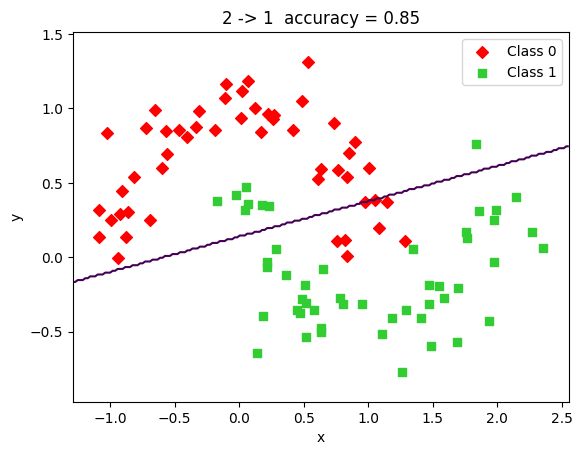

<Sequential name=sequential, built=True>

In [ ]:
model1 = Sequential()

model1.add(
    Dense(
        1,
        input_shape=(2,),
        activation='sigmoid'
    )
)

train_and_plot(model1, "2 -> 1")


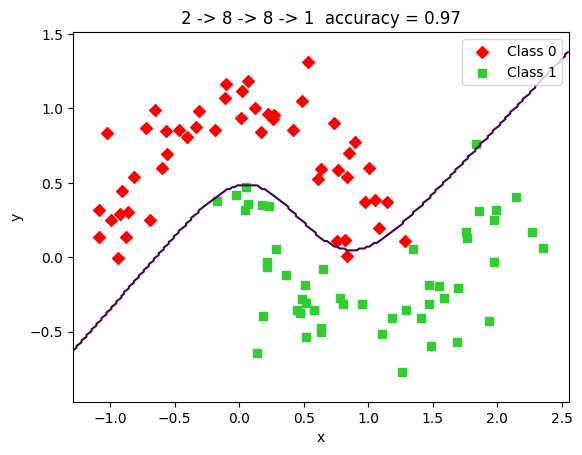

<Sequential name=sequential_9, built=True>

In [ ]:
model2 = Sequential()

model2.add(
    Dense(
        8,
        input_shape=(2,),
        activation='sigmoid'
    )
)

model2.add(
    Dense(
        8,
        activation='sigmoid'
    )
)

model2.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

train_and_plot(model2, "2 -> 8 -> 8 -> 1")


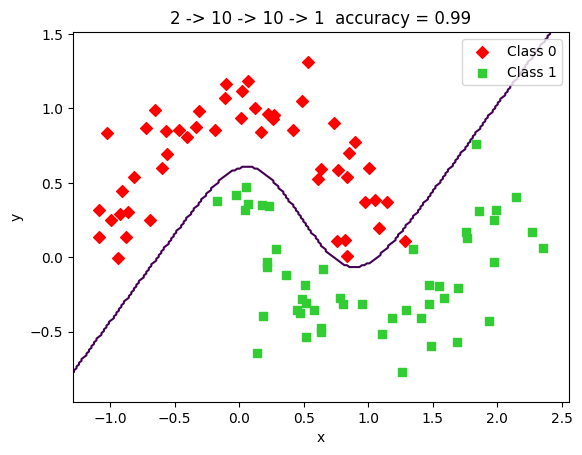

<Sequential name=sequential_2, built=True>

In [ ]:
model3 = Sequential()

model3.add(
    Dense(
        10,
        input_shape=(2,),
        activation='sigmoid'
    )
)

model3.add(
    Dense(
        10,
        activation='sigmoid'
    )
)

model3.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

train_and_plot(model3, "2 -> 10 -> 10 -> 1")